In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("HR_comma_sep.csv")

## Data Info

In [3]:
df.shape

(14999, 10)

In [4]:
df.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [5]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.3 MB


In [7]:
df["Department"].value_counts().index

Index(['sales', 'technical', 'support', 'IT', 'product_mng', 'marketing',
       'RandD', 'accounting', 'hr', 'management'],
      dtype='str', name='Department')

In [8]:
df.duplicated().sum()

np.int64(3008)

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(11991, 10)

## EDA

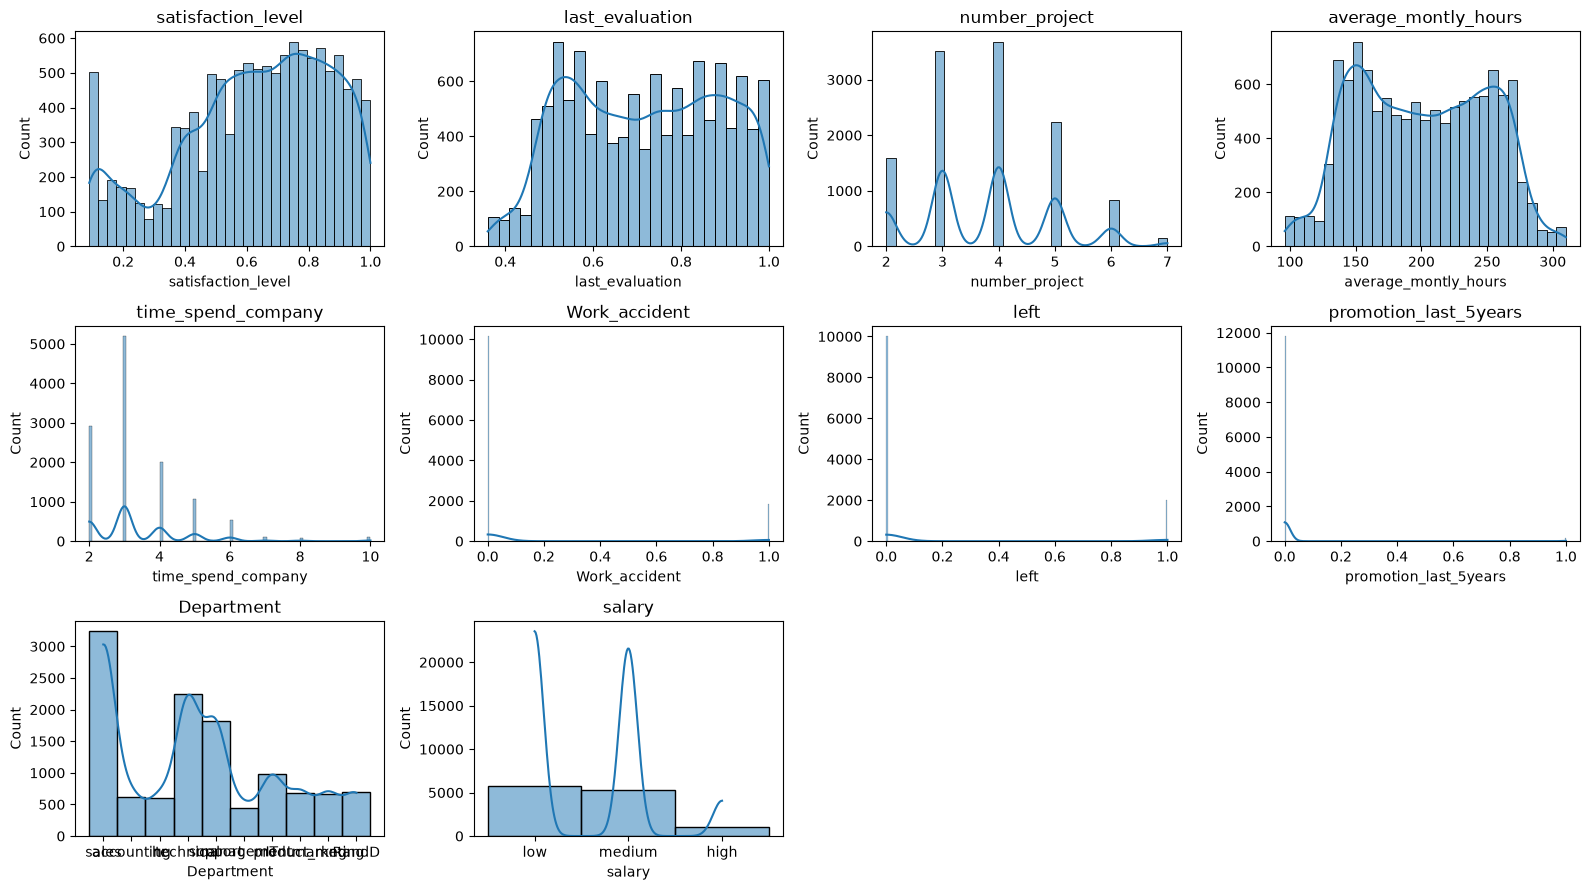

In [12]:
plt.figure(figsize=(16,9))
for i,col in enumerate(df.columns):
    plt.subplot(3,4,i+1)
    sns.histplot(df[col], kde = True)
    plt.title(col)
plt.tight_layout()

<Axes: xlabel='left', ylabel='count'>

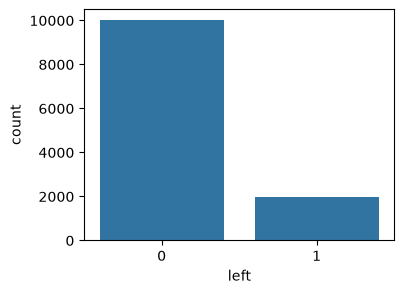

In [13]:
plt.figure(figsize=(4,3))
sns.countplot(x=df["left"])

<Axes: xlabel='satisfaction_level', ylabel='average_montly_hours'>

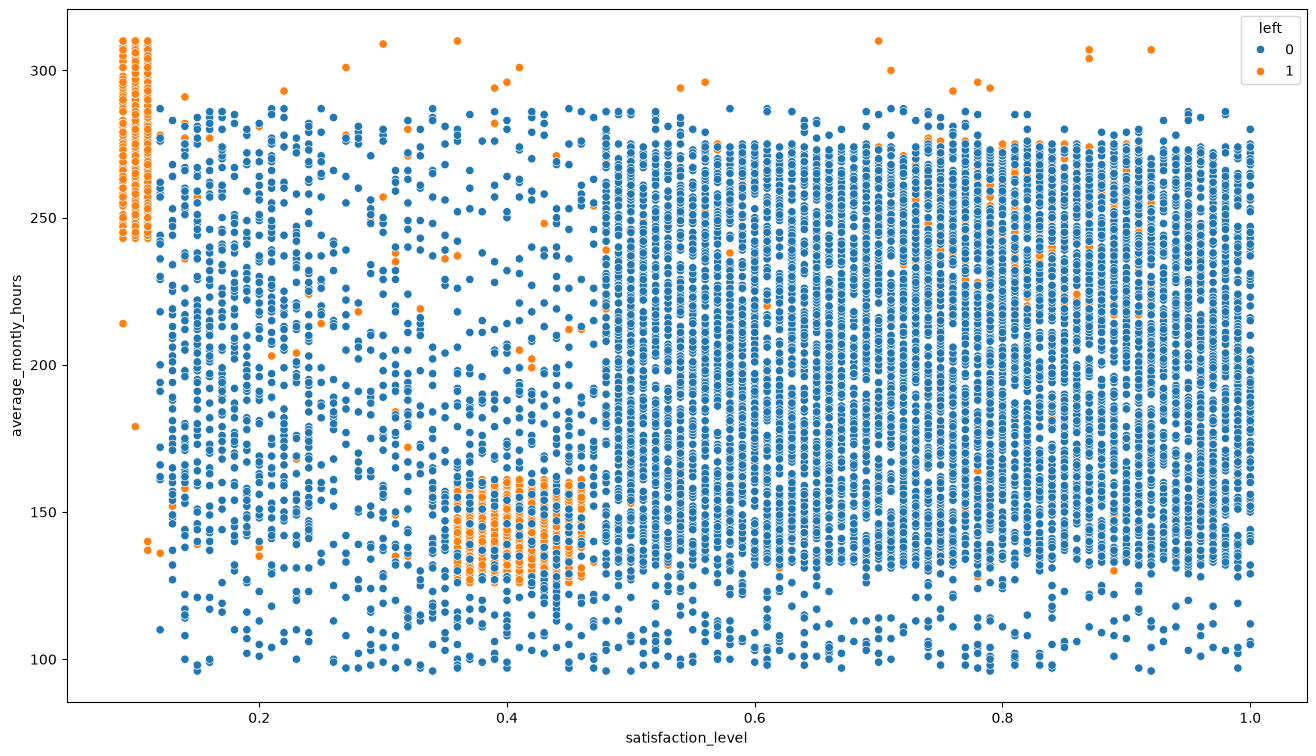

In [14]:
plt.figure(figsize=(16,9))
sns.scatterplot(data=df,x="satisfaction_level",y="average_montly_hours",hue="left")

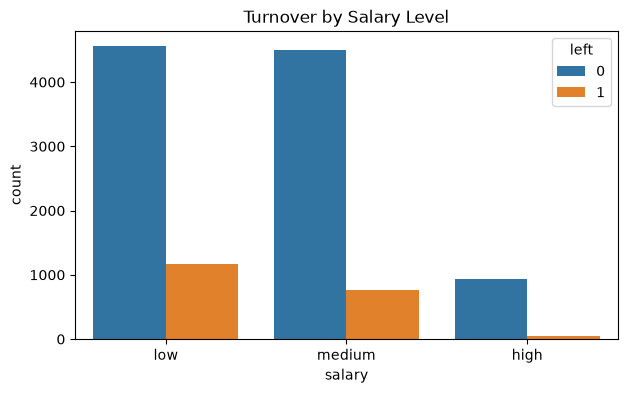

In [15]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='salary', hue='left')
plt.title('Turnover by Salary Level')
plt.show()

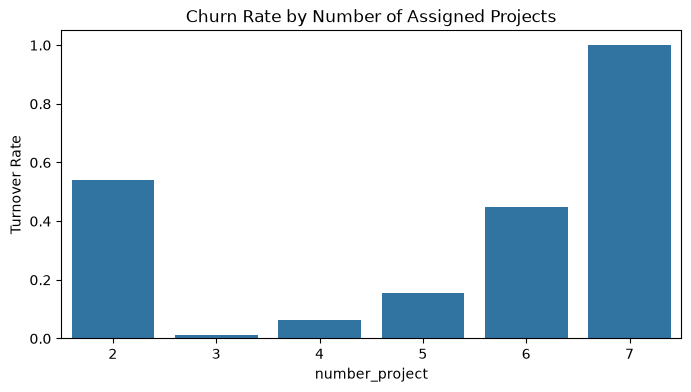

In [16]:
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='number_project', y='left', errorbar=None)
plt.title('Churn Rate by Number of Assigned Projects')
plt.ylabel('Turnover Rate')
plt.show()

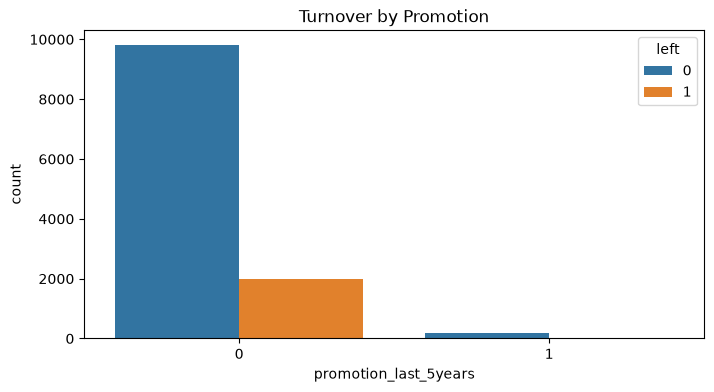

In [17]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='promotion_last_5years', hue='left')
plt.title('Turnover by Promotion')
plt.show()

<Axes: >

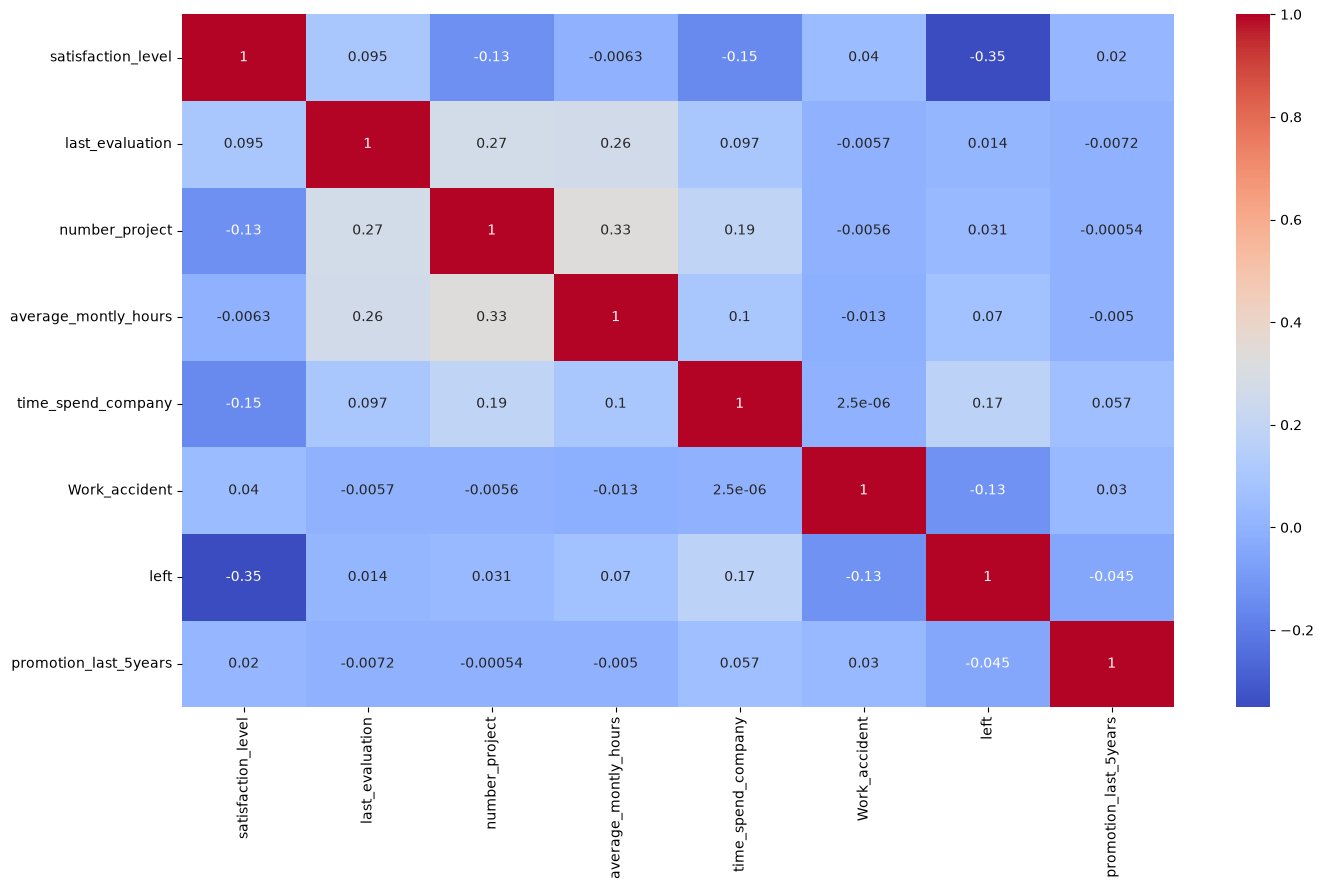

In [18]:
plt.figure(figsize=(16,9))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

## Data Preprocessing

In [19]:
from sklearn.model_selection import train_test_split
X = df.drop("left", axis=1)
y = df["left"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
numerical_features = X_train.select_dtypes(include=["number"]).columns
categorical_features = X_train.select_dtypes(include=["str"]).columns

In [21]:
print("Numerical Features:",numerical_features)
print("Categorical Features:",categorical_features)

Numerical Features: Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years'],
      dtype='str')
Categorical Features: Index(['Department', 'salary'], dtype='str')


In [22]:
X_train["salary"].value_counts()

salary
low       4604
medium    4188
high       800
Name: count, dtype: int64

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer([
    ("numerical_scale", StandardScaler(), list(numerical_features)),
    ("nominal_encode", OneHotEncoder(), ["Department"]),
    ("ordinal_encode", OrdinalEncoder(categories=[["low","medium","high"]]), ["salary"])
])

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight='balanced', random_state=42))
])

In [24]:
model = model_pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9779074614422676
Precision: 0.9728260869565217
Recall: 0.8927680798004988
F1 Score: 0.9310793237971391


In [26]:
from xgboost import XGBClassifier
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",  XGBClassifier(random_state=42))
])
model = model_pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9791579824927052
Precision: 0.968
Recall: 0.9052369077306733
F1 Score: 0.9355670103092784


In [30]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']